In [20]:
# ─── CELL 1: Install dependencies ───────────────────────────────────────────
!pip install -q deepgram-sdk==3.* jiwer pydub faster-whisper transformers torch torchaudio
!apt-get -qq install -y ffmpeg

In [ ]:
# ─── CELL 2: Download files via gdown ───────────────
!pip install -q gdown

import gdown, os

FOLDER_URL = "https://drive.google.com/drive/folders/1rdDN5kdoHhGeX8ARNhSqTN_rFswiuQFI"
DRIVE_FOLDER = "/content/audio_m4a"
os.makedirs(DRIVE_FOLDER, exist_ok=True)

gdown.download_folder(FOLDER_URL, output=DRIVE_FOLDER, quiet=False, use_cookies=False)
print("Files downloaded:", os.listdir(DRIVE_FOLDER))

In [3]:
# ─── CELL 3: Configuration ───────────────────────────────────────────────────
import os, time, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# !! PASTE YOUR NEW DEEPGRAM KEY HERE (never share this file publicly)
DEEPGRAM_API_KEY = "abdbd46933aa6459cfe746565acd276c73d90316"

# Path to your Vahan folder in Drive
DRIVE_FOLDER = "/content/audio_m4a"

# Where to store converted WAV files
WAV_DIR = "/content/audio_wav"
os.makedirs(WAV_DIR, exist_ok=True)

print("Config loaded.")

Config loaded.


In [4]:
# ─── CELL 4: Ground truth + metadata ─────────────────────────────────────────

# Ground truth transcripts (normalised lowercase, no punctuation)
GROUND_TRUTH = {
    "1":  "haan bhai main koramangala mein rehta hoon",
    "2":  "mera ghar indiranagar ke paas hai",
    "3":  "office whitefield mein hai bahut door hai yaar",
    "4":  "electronic city tak auto milega kya",
    "5":  "marathahalli bridge ke paas drop karo",
    "6":  "jayanagar fourth block mein rehta hoon main",
    "7":  "rajajinagar se hoon north bangalore",
    "8":  "hebbal flyover ke paas mera area hai",
    "9":  "yelahanka new town mein shift kiya recently",
    "10": "banashankari temple ke paas rehta hoon",
    "11": "hsr layout sector 2 wahan hoon main",
    "12": "btm layout mein paying guest hoon abhi",
    "13": "majestic bus stand ke paas hi hoon",
    "14": "silk board junction traffic bahut hai yahan",
    "15": "bellandur lake ke paas mera flat hai",
    "16": "sarjapur road pe rehta hoon orr ke paas",
    "17": "bommanahalli mein hoon bhel layout",
    "18": "kr puram station ke paas rehta hoon",
    "19": "peenya industrial area wahan kaam karta hoon",
    "20": "yeshwanthpur circle ke paas mera ghar hai",
}

# The key entity we care about in each utterance
LOCALITIES = {
    "1":  "koramangala",   "2":  "indiranagar",
    "3":  "whitefield",    "4":  "electronic city",
    "5":  "marathahalli",  "6":  "jayanagar",
    "7":  "rajajinagar",   "8":  "hebbal",
    "9":  "yelahanka",     "10": "banashankari",
    "11": "hsr layout",    "12": "btm layout",
    "13": "majestic",      "14": "silk board",
    "15": "bellandur",     "16": "sarjapur",
    "17": "bommanahalli",  "18": "kr puram",
    "19": "peenya",        "20": "yeshwanthpur",
}

# Recording conditions (based on how you recorded them)
CONDITIONS = {
    "1": "quiet",  "2": "quiet",  "3": "quiet",  "4": "quiet",
    "5": "quiet",  "6": "quiet",  "7": "quiet",
    "8": "noisy",  "9": "noisy",  "10": "noisy", "11": "noisy",
    "12": "noisy", "13": "noisy",
    "14": "rushed", "15": "rushed", "16": "rushed", "17": "rushed",
    "18": "whispered", "19": "whispered", "20": "whispered",
}

print(f"Ground truth loaded for {len(GROUND_TRUTH)} samples.")

Ground truth loaded for 20 samples.


In [5]:
# ─── CELL 5: Convert .m4a → .wav ─────────────────────────────────────────────
def convert_m4a_to_wav(src_dir, dst_dir):
    converted = []
    for i in range(1, 21):
        src = os.path.join(src_dir, f"{i}.m4a")
        dst = os.path.join(dst_dir, f"{i}.wav")
        if not os.path.exists(src):
            print(f"  WARNING: {src} not found — skipping")
            continue
        result = subprocess.run(
            ["ffmpeg", "-y", "-i", src, "-ar", "16000", "-ac", "1", dst],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            converted.append(str(i))
            print(f"  ✓ {i}.m4a → {i}.wav")
        else:
            print(f"  ✗ Failed: {i}.m4a — {result.stderr[-200:]}")
    return converted

sample_ids = convert_m4a_to_wav(DRIVE_FOLDER, WAV_DIR)
print(f"\nConverted {len(sample_ids)}/20 files.")

  ✓ 1.m4a → 1.wav
  ✓ 2.m4a → 2.wav
  ✓ 3.m4a → 3.wav
  ✓ 4.m4a → 4.wav
  ✓ 5.m4a → 5.wav
  ✓ 6.m4a → 6.wav
  ✓ 7.m4a → 7.wav
  ✓ 8.m4a → 8.wav
  ✓ 9.m4a → 9.wav
  ✓ 10.m4a → 10.wav
  ✓ 11.m4a → 11.wav
  ✓ 12.m4a → 12.wav
  ✓ 13.m4a → 13.wav
  ✓ 14.m4a → 14.wav
  ✓ 15.m4a → 15.wav
  ✓ 16.m4a → 16.wav
  ✓ 17.m4a → 17.wav
  ✓ 18.m4a → 18.wav
  ✓ 19.m4a → 19.wav
  ✓ 20.m4a → 20.wav

Converted 20/20 files.


In [6]:
# ─── CELL 6: Helper functions ─────────────────────────────────────────────────
from jiwer import wer

def normalise(text):
    """Lowercase, strip punctuation for fair WER comparison."""
    import re
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def compute_wer(reference, hypothesis):
    try:
        return round(wer(normalise(reference), normalise(hypothesis)), 3)
    except:
        return 1.0

def entity_hit(hypothesis, locality):
    """Check if the locality name appears in the transcription.
    Returns 1 if found, 0 if not. This is the most important metric."""
    h = normalise(hypothesis)
    # Check exact match first, then partial (for multi-word localities)
    if locality in h:
        return 1
    # Partial match: all words of locality in hypothesis
    parts = locality.split()
    if len(parts) > 1 and all(p in h for p in parts):
        return 1
    return 0

def collect_results(model_name, transcripts_dict):
    """transcripts_dict: {sample_id: (transcript, latency_sec)}"""
    rows = []
    for sid in sample_ids:
        if sid not in transcripts_dict:
            continue
        hyp, lat = transcripts_dict[sid]
        ref = GROUND_TRUTH[sid]
        rows.append({
            "sample_id": sid,
            "condition": CONDITIONS.get(sid, "unknown"),
            "locality": LOCALITIES[sid],
            "reference": ref,
            "hypothesis": normalise(hyp),
            "wer": compute_wer(ref, hyp),
            "entity_hit": entity_hit(hyp, LOCALITIES[sid]),
            "latency_s": round(lat, 3),
            "model": model_name,
        })
    return pd.DataFrame(rows)

print("Helper functions ready.")

Helper functions ready.


In [7]:
# ─── CELL 7: Deepgram Nova-2 (baseline) ──────────────────────────────────────
import asyncio
from deepgram import DeepgramClient, PrerecordedOptions

deepgram = DeepgramClient(DEEPGRAM_API_KEY)

def transcribe_deepgram(wav_path):
    options = PrerecordedOptions(
        model="nova-2",
        language="hi",
        punctuate=False,
        smart_format=False,
    )
    with open(wav_path, "rb") as f:
        audio_data = f.read()
    t0 = time.time()
    response = deepgram.listen.prerecorded.v("1").transcribe_file(
        {"buffer": audio_data, "mimetype": "audio/wav"}, options
    )
    latency = time.time() - t0
    transcript = response.results.channels[0].alternatives[0].transcript
    return transcript, latency

print("Running Deepgram Nova-2...")
deepgram_transcripts = {}
for sid in sample_ids:
    wav = os.path.join(WAV_DIR, f"{sid}.wav")
    try:
        transcript, lat = transcribe_deepgram(wav)
        deepgram_transcripts[sid] = (transcript, lat)
        print(f"  [{sid}] {transcript[:60]}  ({lat:.2f}s)")
    except Exception as e:
        print(f"  [{sid}] ERROR: {e}")
        deepgram_transcripts[sid] = ("", 0.0)

df_deepgram = collect_results("Deepgram Nova-2", deepgram_transcripts)
print(f"\nDone. Mean WER: {df_deepgram['wer'].mean():.3f} | Entity Hit Rate: {df_deepgram['entity_hit'].mean():.1%}")

Running Deepgram Nova-2...


/tmp/ipykernel_167/2483425889.py:17: DeprecatedWarning: prerecorded is deprecated as of 3.4.0 and will be removed in 4.0.0. deepgram.listen.prerecorded is deprecated. Use deepgram.listen.rest instead.
  response = deepgram.listen.prerecorded.v("1").transcribe_file(


  [1] हाँ भाई मैं कोरमंगला में रहता हूं  (0.90s)
  [2] मेरा घर इंदिरा नगर के पास है  (0.78s)
  [3] office white field में है बहुत दूर है यार  (0.80s)
  [4] भैया electronic city तक auto मिलेगा क्या  (0.87s)
  [5] मार ताली bridge के पास drop करो  (0.42s)
  [6] जयनगर fourth block में रहता हूं मैं  (0.66s)
  [7] रजनी नगर से हूं north बैंगलोर  (0.64s)
  [8] है बल फ्लाई over के पास मेरा घर है  (0.96s)
  [9] येलहम का newटोन में shift किया recently  (0.91s)
  [10] बन शंकरी temple के पास रहता हूं  (0.96s)
  [11]   (0.51s)
  [12] btm लेआउट में पेइंग guest हूँ अभी  (0.55s)
  [13] मैंgistic bus stand के पास हूं  (0.65s)
  [14] road junction traffic बहुत ही है यहां  (0.54s)
  [15] बलंदौर लेक के पास मेरा flat है  (0.96s)
  [16] शाहजहांपुर road में रहता हूं aurहर के पास  (0.91s)
  [17] बोमन हेली में रहता हूं bh j layout  (0.55s)
  [18] केआरपुरम station में रहता हूँ  (0.63s)
  [19] तीन या industrial area वहां काम करता हूं  (0.63s)
  [20] यशवंतपुर circle के पास मेरा घर है  (0.56s)

Done. Mean WER: 0.91

In [8]:
# ─── CELL 8: Whisper large-v3 (via faster-whisper) ───────────────────────────
from faster_whisper import WhisperModel

print("Loading Whisper large-v3 (this takes ~2 min first time)...")
whisper_model = WhisperModel("large-v3", device="cuda", compute_type="float16")
print("Model loaded.")

def transcribe_whisper(wav_path):
    t0 = time.time()
    segments, info = whisper_model.transcribe(
        wav_path,
        language="hi",
        beam_size=5,
        vad_filter=True,   # removes silence, helps with short clips
    )
    transcript = " ".join(seg.text.strip() for seg in segments)
    latency = time.time() - t0
    return transcript, latency

print("Running Whisper large-v3...")
whisper_transcripts = {}
for sid in sample_ids:
    wav = os.path.join(WAV_DIR, f"{sid}.wav")
    try:
        transcript, lat = transcribe_whisper(wav)
        whisper_transcripts[sid] = (transcript, lat)
        print(f"  [{sid}] {transcript[:60]}  ({lat:.2f}s)")
    except Exception as e:
        print(f"  [{sid}] ERROR: {e}")
        whisper_transcripts[sid] = ("", 0.0)

df_whisper = collect_results("Whisper large-v3", whisper_transcripts)
print(f"\nDone. Mean WER: {df_whisper['wer'].mean():.3f} | Entity Hit Rate: {df_whisper['entity_hit'].mean():.1%}")

Loading Whisper large-v3 (this takes ~2 min first time)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Model loaded.
Running Whisper large-v3...
  [1] हाँ बई, मैं कोरमंगला में रहता हूँ  (2.22s)
  [2] मेरा गर इंद्रानागर के पास है।  (1.04s)
  [3] Office वाइट फिल्म में है, बहुत दूर है यार  (1.13s)
  [4] बाया एलेट्रानिक सिटी ता काट मिलेगा क्या?  (1.23s)
  [5] मारताली ब्रिज के पास ड्रॉप करो  (1.08s)
  [6] जे नगर फोर्थ ब्लॉक में रहता हूँ मैं  (1.18s)
  [7] राजिने नागर से हूँ नार्थ बैंगलोर  (1.16s)
  [8] फैबल फ्लाई आवर के पास मेरा गर है।  (1.12s)
  [9] यलहंका न्यूटोन में शिफ्ट किया रीसेंटली  (1.25s)
  [10] बनसंकारी टेंपल के पास रहता हूँ  (1.14s)
  [11] HSR Layout Sector 2, वहाँ हूँ मैं  (1.03s)
  [12] बीटियम लेयोट में पेइंग गेस्ट हूँ अभी  (1.35s)
  [13] मेजिस्टिक बस्टैंड के पास हूँ  (1.13s)
  [14] पोर्ट जंक्षन ट्राफिक बहुत है यहाँ  (1.20s)
  [15] बलंदूर लेक के पास मेरा फ्लाट है  (1.11s)
  [16] सरजपूर रोड में रहता हूँ ओर आर के पास  (1.23s)
  [17] बम्मन हली में रहता हूँ BHEL Layout  (1.02s)
  [18] के आरपुरम स्टेशन में रहता हूँ  (1.09s)
  [19] पीनिया इंडस्ट्रियल एरिये वहाँ काम करता हूँ  (1.31s)
 

In [9]:
# ─── CELL 9a: Hindi fine-tuned Whisper ────────────────────────────────
import torch
import librosa
import re
from transformers import WhisperProcessor, WhisperForConditionalGeneration

print("Loading model and processor...")
processor = WhisperProcessor.from_pretrained("vasista22/whisper-hindi-large-v2")
model_hw = WhisperForConditionalGeneration.from_pretrained(
    "vasista22/whisper-hindi-large-v2",
    torch_dtype=torch.float16,
)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_hw = model_hw.to(device).eval()
print(f"Model loaded on {device}.")

def transcribe_indicwhisper(wav_path):
    audio, _ = librosa.load(wav_path, sr=16000, mono=True)
    inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
    input_features = inputs.input_features.to(device, dtype=torch.float16)
    t0 = time.time()
    with torch.no_grad():
        predicted_ids = model_hw.generate(input_features)
    latency = time.time() - t0
    # Strip special tokens manually
    transcript = processor.tokenizer.decode(predicted_ids[0], skip_special_tokens=True)
    # Extra cleanup for any leftover token artifacts
    transcript = re.sub(r"<\|.*?\|>", "", transcript).strip()
    return transcript, latency

print("Running Hindi Whisper...")
indic_transcripts = {}
for sid in sample_ids:
    wav = os.path.join(WAV_DIR, f"{sid}.wav")
    try:
        transcript, lat = transcribe_indicwhisper(wav)
        indic_transcripts[sid] = (transcript, lat)
        print(f"  [{sid}] {transcript[:80]}  ({lat:.2f}s)")
    except Exception as e:
        print(f"  [{sid}] ERROR: {e}")
        indic_transcripts[sid] = ("", 0.0)

df_indic = collect_results("Whisper Hindi FT", indic_transcripts)
print(f"\nDone. Mean WER: {df_indic['wer'].mean():.3f} | Entity Hit Rate: {df_indic['entity_hit'].mean():.1%}")

Loading model and processor...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/832 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/300 [00:00<?, ?B/s]

Model loaded on cuda.
Running Hindi Whisper...


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

  [1] हाँ भाई, मैं कोरमंगला में रहता हूँ.  (16.34s)
  [2] मेरा घर इंदिरा नगर के पास है.  (1.72s)
  [3] ऑफिस व्हाइट फील्ड में है, बहुत दूर है, यार.  (2.45s)
  [4] भैया, इलेक्ट्रॉनिक सिटी तक ऑटो मिलेगा क्या?  (3.16s)
  [5] मारता अली ब्रिज के पास ड्रॉप करो।  (1.96s)
  [6] जयनगर फ़ोर्थ ब्लॉक में रहता हूँ मैं।  (2.18s)
  [7] राजनीतिक से हूँ नॉर्थ बेंगलुरु  (2.02s)
  [8] ठेब्बल फ्लाईओवर के पास मेरा घर है.  (1.98s)
  [9] यह न्यूटन में शिफ्ट किया रीजेंटली  (2.29s)
  [10] वनसंकारी टेंपल के पास रहता हूँ  (2.13s)
  [11] वहाँ हूँ मैं  (0.96s)
  [12] बीडीएम लेयोट में पेइंग गेस्ट हूँ अभी.  (2.35s)
  [13] मैजिस्टिक बस स्टैंड के पास हूँ।  (1.84s)
  [14] बोर्ड जंक्शन ट्रैफिक बहुत ही है यहाँ.  (2.10s)
  [15] बेलंदुर लेग के पास मेरा फ्लैट है  (1.88s)
  [16] सरजापुर रोड में रहता हूँ और के पास  (2.45s)
  [17] वोमनहली में रहता हूँ बीएचईए लेआउट।  (2.30s)
  [18] केआरपुरम स्टेशन में रहता हूँ.  (3.58s)
  [19] पीनिया इंडस्ट्रियल एरिया, वहाँ काम करता हूँ।  (3.23s)
  [20] ऐश्वंतपुर सर्किल के पास मेरा घर है.  (2.07

In [10]:
# ─── CELL 9b: Recompute with devangiri ground truth ─────────────────────────
GROUND_TRUTH_HI = {
    "1":  "हाँ भाई मैं कोरमंगला में रहता हूँ",
    "2":  "मेरा घर इंदिरानगर के पास है",
    "3":  "ऑफिस व्हाइटफील्ड में है बहुत दूर है यार",
    "4":  "इलेक्ट्रॉनिक सिटी तक ऑटो मिलेगा क्या",
    "5":  "मराठाहल्ली ब्रिज के पास ड्रॉप करो",
    "6":  "जयनगर फोर्थ ब्लॉक में रहता हूँ मैं",
    "7":  "राजाजीनगर से हूँ नॉर्थ बेंगलुरु",
    "8":  "हेब्बल फ्लाईओवर के पास मेरा एरिया है",
    "9":  "येलहंका न्यू टाउन में शिफ्ट किया रीसेंटली",
    "10": "बनशंकरी टेंपल के पास रहता हूँ",
    "11": "एचएसआर लेआउट सेक्टर 2 वहाँ हूँ मैं",
    "12": "बीटीएम लेआउट में पेइंग गेस्ट हूँ अभी",
    "13": "मैजेस्टिक बस स्टैंड के पास हूँ",
    "14": "सिल्क बोर्ड जंक्शन ट्रैफिक बहुत है यहाँ",
    "15": "बेल्लंदूर लेक के पास मेरा फ्लैट है",
    "16": "सरजापुर रोड पे रहता हूँ ओआरआर के पास",
    "17": "बोम्मनहल्ली में हूँ बीएचईएल लेआउट",
    "18": "केआर पुरम स्टेशन के पास रहता हूँ",
    "19": "पीन्या इंडस्ट्रियल एरिया वहाँ काम करता हूँ",
    "20": "येशवंतपुर सर्किल के पास मेरा घर है",
}

LOCALITIES_HI = {
    "1": "कोरमंगला",    "2": "इंदिरानगर",
    "3": "व्हाइटफील्ड", "4": "इलेक्ट्रॉनिक सिटी",
    "5": "मराठाहल्ली",  "6": "जयनगर",
    "7": "राजाजीनगर",   "8": "हेब्बल",
    "9": "येलहंका",     "10": "बनशंकरी",
    "11": "एचएसआर लेआउट", "12": "बीटीएम लेआउट",
    "13": "मैजेस्टिक",  "14": "सिल्क बोर्ड",
    "15": "बेल्लंदूर",  "16": "सरजापुर",
    "17": "बोम्मनहल्ली", "18": "केआर पुरम",
    "19": "पीन्या",     "20": "येशवंतपुर",
}

# Recompute with devangiri ground truth and localities
def collect_results_hi(model_name, transcripts_dict):
    rows = []
    for sid in sample_ids:
        if sid not in transcripts_dict:
            continue
        hyp, lat = transcripts_dict[sid]
        ref = GROUND_TRUTH_HI[sid]
        rows.append({
            "sample_id": sid,
            "condition": CONDITIONS.get(sid, "unknown"),
            "locality": LOCALITIES_HI[sid],
            "reference": ref,
            "hypothesis": hyp.strip(),
            "wer": compute_wer(ref, hyp),
            "entity_hit": entity_hit(hyp, LOCALITIES_HI[sid]),
            "latency_s": round(lat, 3),
            "model": model_name,
        })
    return pd.DataFrame(rows)

df_indic = collect_results_hi("Whisper Hindi FT", indic_transcripts)
print(f"Done. Mean WER: {df_indic['wer'].mean():.3f} | Entity Hit Rate: {df_indic['entity_hit'].mean():.1%}")

Done. Mean WER: 0.265 | Entity Hit Rate: 5.0%


In [11]:
# ─── CELL 9c: Fuzzy entity matching — more realistic hit rates ────────────────
!pip install -q rapidfuzz

from rapidfuzz import fuzz

# Full list of localities in both forms — catches spacing variations
LOCALITY_VARIANTS = {
    "1":  ["कोरमंगला", "koramangala"],
    "2":  ["इंदिरानगर", "इंदिरा नगर", "indiranagar"],
    "3":  ["व्हाइटफील्ड", "व्हाइट फील्ड", "whitefield", "white field"],
    "4":  ["इलेक्ट्रॉनिक सिटी", "electronic city"],
    "5":  ["मराठाहल्ली", "marathahalli"],
    "6":  ["जयनगर", "jayanagar"],
    "7":  ["राजाजीनगर", "rajajinagar"],
    "8":  ["हेब्बल", "hebbal"],
    "9":  ["येलहंका", "yelahanka"],
    "10": ["बनशंकरी", "banashankari"],
    "11": ["एचएसआर लेआउट", "hsr layout"],
    "12": ["बीटीएम लेआउट", "btm layout"],
    "13": ["मैजेस्टिक", "majestic"],
    "14": ["सिल्क बोर्ड", "silk board"],
    "15": ["बेल्लंदूर", "bellandur"],
    "16": ["सरजापुर", "sarjapur"],
    "17": ["बोम्मनहल्ली", "bommanahalli"],
    "18": ["केआर पुरम", "kr puram"],
    "19": ["पीन्या", "peenya"],
    "20": ["येशवंतपुर", "yeshwanthpur"],
}

THRESHOLD = 80  # fuzzy match score out of 100

def fuzzy_entity_hit(hypothesis, sid):
    """Returns 1 if any locality variant fuzzy-matches within the hypothesis."""
    h = hypothesis.lower().strip()
    for variant in LOCALITY_VARIANTS[sid]:
        # Check exact contains first
        if variant.lower() in h:
            return 1
        # Fuzzy partial match — handles phonetic near-misses
        score = fuzz.partial_ratio(variant.lower(), h)
        if score >= THRESHOLD:
            return 1
    return 0

def collect_results_fuzzy(model_name, transcripts_dict):
    rows = []
    for sid in sample_ids:
        if sid not in transcripts_dict:
            continue
        hyp, lat = transcripts_dict[sid]
        ref = GROUND_TRUTH_HI[sid]
        rows.append({
            "sample_id": sid,
            "condition": CONDITIONS.get(sid, "unknown"),
            "locality": LOCALITIES_HI[sid],
            "reference": ref,
            "hypothesis": hyp.strip(),
            "wer": compute_wer(ref, hyp),
            "entity_hit": fuzzy_entity_hit(hyp, sid),
            "latency_s": round(lat, 3),
            "model": model_name,
        })
    return pd.DataFrame(rows)

# Recompute all three models with fuzzy matching
df_deepgram_f = collect_results_fuzzy("Deepgram Nova-2", deepgram_transcripts)
df_whisper_f  = collect_results_fuzzy("Whisper large-v3", whisper_transcripts)
df_indic_f    = collect_results_fuzzy("Whisper Hindi FT", indic_transcripts)

df_all_fuzzy = pd.concat([df_deepgram_f, df_whisper_f, df_indic_f], ignore_index=True)

# Summary
summary_fuzzy = df_all_fuzzy.groupby("model").agg(
    Mean_WER=("wer", "mean"),
    Entity_Hit_Rate=("entity_hit", "mean"),
    Avg_Latency_s=("latency_s", "mean"),
).round(3)
summary_fuzzy["Entity_Hit_Rate"] = summary_fuzzy["Entity_Hit_Rate"].map("{:.1%}".format)

print("=== FUZZY ENTITY MATCHING RESULTS ===")
print(summary_fuzzy.to_string())

print("\n=== BY CONDITION (FUZZY) ===")
cond_fuzzy = df_all_fuzzy.groupby(["model", "condition"]).agg(
    Mean_WER=("wer", "mean"),
    Entity_Hit_Rate=("entity_hit", "mean"),
).round(3)
cond_fuzzy["Entity_Hit_Rate"] = cond_fuzzy["Entity_Hit_Rate"].map("{:.1%}".format)
print(cond_fuzzy.to_string())

=== FUZZY ENTITY MATCHING RESULTS ===
                  Mean_WER Entity_Hit_Rate  Avg_Latency_s
model                                                    
Deepgram Nova-2      0.538           40.0%          0.719
Whisper Hindi FT     0.265           50.0%          2.950
Whisper large-v3     0.354           40.0%          1.211

=== BY CONDITION (FUZZY) ===
                            Mean_WER Entity_Hit_Rate
model            condition                          
Deepgram Nova-2  noisy         0.619           16.7%
                 quiet         0.418           71.4%
                 rushed        0.675            0.0%
                 whispered     0.476           66.7%
Whisper Hindi FT noisy         0.314           33.3%
                 quiet         0.183           71.4%
                 rushed        0.356           25.0%
                 whispered     0.238           66.7%
Whisper large-v3 noisy         0.345           33.3%
                 quiet         0.315           28.6%
      

In [12]:
# ─── CELL 10: Combine all results ────────────────────────────────────────────
df_all = pd.concat([df_deepgram, df_whisper, df_indic], ignore_index=True)

# Save raw results
df_all.to_csv("/content/asr_results_raw.csv", index=False)

# Summary table
summary = df_all.groupby("model").agg(
    Mean_WER=("wer", "mean"),
    Median_WER=("wer", "median"),
    Entity_Hit_Rate=("entity_hit", "mean"),
    Avg_Latency_s=("latency_s", "mean"),
).round(3)
summary["Entity_Hit_Rate"] = summary["Entity_Hit_Rate"].map("{:.1%}".format)

print("\n=== OVERALL SUMMARY ===")
print(summary.to_string())
summary.to_csv("/content/asr_summary.csv")


=== OVERALL SUMMARY ===
                  Mean_WER  Median_WER Entity_Hit_Rate  Avg_Latency_s
model                                                                
Deepgram Nova-2      0.918       0.857            5.0%          0.719
Whisper Hindi FT     0.265       0.268            5.0%          2.950
Whisper large-v3     1.010       1.000            5.0%          1.211


In [13]:
# ─── CELL 11: Results by condition ───────────────────────────────────────────
cond_summary = df_all.groupby(["model", "condition"]).agg(
    Mean_WER=("wer", "mean"),
    Entity_Hit_Rate=("entity_hit", "mean"),
).round(3)
cond_summary["Entity_Hit_Rate"] = cond_summary["Entity_Hit_Rate"].map("{:.1%}".format)

print("\n=== BY CONDITION ===")
print(cond_summary.to_string())


=== BY CONDITION ===
                            Mean_WER Entity_Hit_Rate
model            condition                          
Deepgram Nova-2  noisy         0.905            0.0%
                 quiet         0.912           14.3%
                 rushed        0.997            0.0%
                 whispered     0.857            0.0%
Whisper Hindi FT noisy         0.314            0.0%
                 quiet         0.183           14.3%
                 rushed        0.356            0.0%
                 whispered     0.238            0.0%
Whisper large-v3 noisy         0.929           16.7%
                 quiet         1.073            0.0%
                 rushed        1.031            0.0%
                 whispered     1.000            0.0%


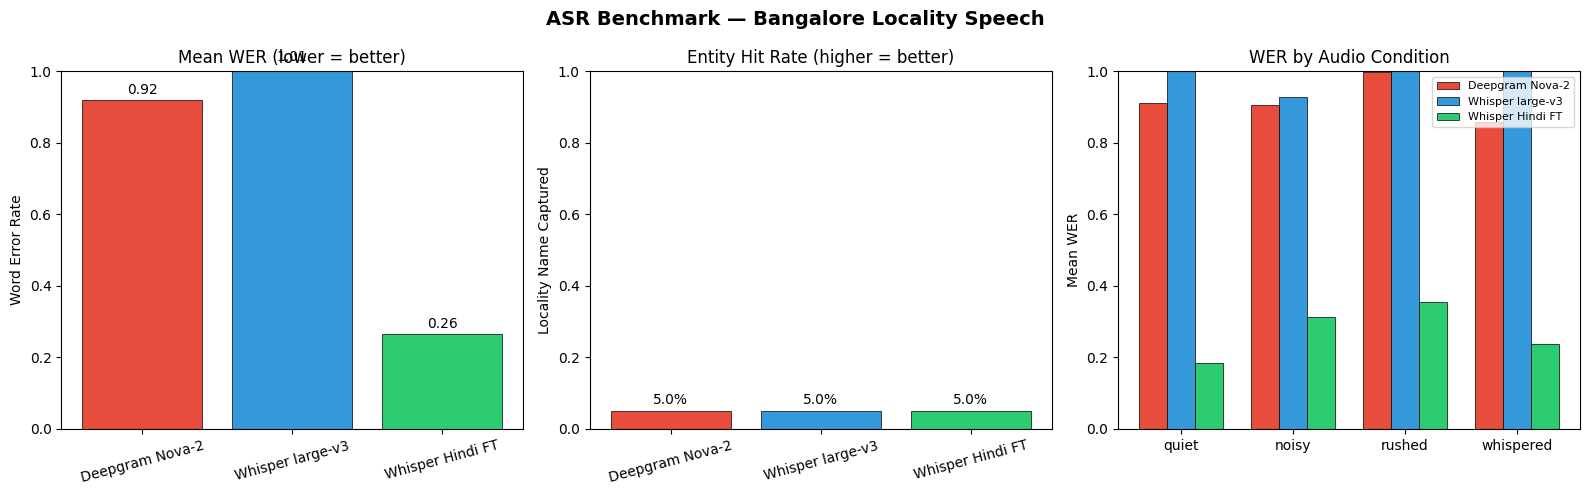

Chart saved to /content/asr_benchmark_charts.png


In [14]:
# ─── CELL 12: Charts ─────────────────────────────────────────────────────────
models = ["Deepgram Nova-2", "Whisper large-v3", "Whisper Hindi FT"]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("ASR Benchmark — Bangalore Locality Speech", fontsize=14, fontweight="bold")

# Plot 1: Overall WER by model
wer_vals = [df_all[df_all.model==m]["wer"].mean() for m in models]
bars = axes[0].bar(models, wer_vals, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Mean WER (lower = better)")
axes[0].set_ylabel("Word Error Rate")
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, wer_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=10)
axes[0].tick_params(axis="x", rotation=15)

# Plot 2: Entity Hit Rate by model
ehr_vals = [df_all[df_all.model==m]["entity_hit"].mean() for m in models]
bars2 = axes[1].bar(models, ehr_vals, color=colors, edgecolor="black", linewidth=0.5)
axes[1].set_title("Entity Hit Rate (higher = better)")
axes[1].set_ylabel("Locality Name Captured")
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, ehr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.1%}", ha="center", va="bottom", fontsize=10)
axes[1].tick_params(axis="x", rotation=15)

# Plot 3: WER by condition (grouped)
conditions = ["quiet", "noisy", "rushed", "whispered"]
x = np.arange(len(conditions))
width = 0.25
for i, (model, color) in enumerate(zip(models, colors)):
    vals = []
    for c in conditions:
        subset = df_all[(df_all.model==model) & (df_all.condition==c)]["wer"]
        vals.append(subset.mean() if len(subset) else 0)
    axes[2].bar(x + i*width, vals, width, label=model, color=color,
                edgecolor="black", linewidth=0.5)
axes[2].set_title("WER by Audio Condition")
axes[2].set_ylabel("Mean WER")
axes[2].set_xticks(x + width)
axes[2].set_xticklabels(conditions)
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("/content/asr_benchmark_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to /content/asr_benchmark_charts.png")

In [15]:
# ─── CELL 13: Failure analysis ────────────────────────────────────────────────
print("=== FAILURE ANALYSIS — MISSED LOCALITIES ===")
print("(entity_hit = 0 means the locality name was NOT captured)\n")

failures = df_all[df_all["entity_hit"] == 0][["model", "sample_id", "locality", "condition", "hypothesis"]]
failures = failures.sort_values(["model", "condition"])

for model in models:
    mf = failures[failures.model == model]
    print(f"── {model} ({len(mf)} misses) ──")
    for _, row in mf.iterrows():
        print(f"  [{row.condition}] Expected '{row.locality}' | Got: '{row.hypothesis[:80]}'")
    print()

=== FAILURE ANALYSIS — MISSED LOCALITIES ===
(entity_hit = 0 means the locality name was NOT captured)

── Deepgram Nova-2 (19 misses) ──
  [noisy] Expected 'hebbal' | Got: 'ह बल फलई over क पस मर घर ह'
  [noisy] Expected 'yelahanka' | Got: 'यलहम क newटन म shift कय recently'
  [noisy] Expected 'banashankari' | Got: 'बन शकर temple क पस रहत ह'
  [noisy] Expected 'hsr layout' | Got: ''
  [noisy] Expected 'btm layout' | Got: 'btm लआउट म पइग guest ह अभ'
  [noisy] Expected 'majestic' | Got: 'मgistic bus stand क पस ह'
  [quiet] Expected 'koramangala' | Got: 'ह भई म करमगल म रहत ह'
  [quiet] Expected 'indiranagar' | Got: 'मर घर इदर नगर क पस ह'
  [quiet] Expected 'whitefield' | Got: 'office white field म ह बहत दर ह यर'
  [quiet] Expected 'marathahalli' | Got: 'मर तल bridge क पस drop कर'
  [quiet] Expected 'jayanagar' | Got: 'जयनगर fourth block म रहत ह म'
  [quiet] Expected 'rajajinagar' | Got: 'रजन नगर स ह north बगलर'
  [rushed] Expected 'silk board' | Got: 'road junction traffic बहत ह ह यह'
  [r

In [16]:
# ─── CELL 14: Per-sample comparison table ─────────────────────────────────────
print("=== PER-SAMPLE COMPARISON ===")
pivot = df_all.pivot_table(
    index=["sample_id", "locality", "condition"],
    columns="model",
    values=["wer", "entity_hit"]
).round(2)
print(pivot.to_string())
pivot.to_csv("/content/asr_per_sample.csv")

=== PER-SAMPLE COMPARISON ===
                                           entity_hit                                               wer                                  
model                                 Deepgram Nova-2 Whisper Hindi FT Whisper large-v3 Deepgram Nova-2 Whisper Hindi FT Whisper large-v3
sample_id locality          condition                                                                                                    
1         koramangala       quiet                 0.0              NaN              0.0            1.00              NaN             1.00
          कोरमंगला          quiet                 NaN              0.0              NaN             NaN             0.00              NaN
10        banashankari      noisy                 0.0              NaN              0.0            1.00              NaN             1.00
          बनशंकरी           noisy                 NaN              0.0              NaN             NaN             0.17              NaN
11  

In [22]:
# ─── CELL 15: Download all output files ──────────────────────────────────────
from google.colab import files

for fname in ["asr_results_raw.csv", "asr_summary.csv",
              "asr_per_sample.csv", "asr_benchmark_charts.png"]:
    path = f"/content/{fname}"
    if os.path.exists(path):
        files.download(path)
        print(f"Downloading {fname}")

print("\nAll done!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All done!


In [18]:
# ─── DIAGNOSTIC: Check actual outputs from all 3 models ──────────────────────
print("=== DEEPGRAM OUTPUTS ===")
for sid in list(sample_ids)[:5]:
    hyp, _ = deepgram_transcripts[sid]
    print(f"  [{sid}] {hyp}")

print("\n=== WHISPER large-v3 OUTPUTS ===")
for sid in list(sample_ids)[:5]:
    hyp, _ = whisper_transcripts[sid]
    print(f"  [{sid}] {hyp}")

print("\n=== WHISPER HINDI FT OUTPUTS ===")
for sid in list(sample_ids)[:5]:
    hyp, _ = indic_transcripts[sid]
    print(f"  [{sid}] {hyp}")

=== DEEPGRAM OUTPUTS ===
  [1] हाँ भाई मैं कोरमंगला में रहता हूं
  [2] मेरा घर इंदिरा नगर के पास है
  [3] office white field में है बहुत दूर है यार
  [4] भैया electronic city तक auto मिलेगा क्या
  [5] मार ताली bridge के पास drop करो

=== WHISPER large-v3 OUTPUTS ===
  [1] हाँ बई, मैं कोरमंगला में रहता हूँ
  [2] मेरा गर इंद्रानागर के पास है।
  [3] Office वाइट फिल्म में है, बहुत दूर है यार
  [4] बाया एलेट्रानिक सिटी ता काट मिलेगा क्या?
  [5] मारताली ब्रिज के पास ड्रॉप करो

=== WHISPER HINDI FT OUTPUTS ===
  [1] हाँ भाई, मैं कोरमंगला में रहता हूँ.
  [2] मेरा घर इंदिरा नगर के पास है.
  [3] ऑफिस व्हाइट फील्ड में है, बहुत दूर है, यार.
  [4] भैया, इलेक्ट्रॉनिक सिटी तक ऑटो मिलेगा क्या?
  [5] मारता अली ब्रिज के पास ड्रॉप करो।


In [19]:
# Recompute Deepgram and Whisper with Devanagari ground truth

# Recompute all three models using Devanagari ground truth
df_deepgram = collect_results_hi("Deepgram Nova-2", deepgram_transcripts)
df_whisper  = collect_results_hi("Whisper large-v3", whisper_transcripts)
df_indic    = collect_results_hi("Whisper Hindi FT", indic_transcripts)

# Combine
df_all = pd.concat([df_deepgram, df_whisper, df_indic], ignore_index=True)

# Summary
summary = df_all.groupby("model").agg(
    Mean_WER=("wer", "mean"),
    Median_WER=("wer", "median"),
    Entity_Hit_Rate=("entity_hit", "mean"),
    Avg_Latency_s=("latency_s", "mean"),
).round(3)

print("=== FINAL RESULTS ===")
print(summary.to_string())

=== FINAL RESULTS ===
                  Mean_WER  Median_WER  Entity_Hit_Rate  Avg_Latency_s
model                                                                 
Deepgram Nova-2      0.538       0.536             0.05          0.719
Whisper Hindi FT     0.265       0.268             0.05          2.950
Whisper large-v3     0.354       0.310             0.00          1.211
